<a href="https://colab.research.google.com/github/DariaChernykh4/DA-projects/blob/main/E_Commerce_Sales_%26_Traffic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Introduction**



This project presents a comprehensive sales analytics report for an e-commerce furniture store, built using SQL, Python, and Tableau.

**Objective**
The goal of this analysis is to explore customer behavior, revenue
dynamics, and business performance across geography, product categories,
traffic channels, and user segments — and to derive actionable insights
that can guide business decisions.

**Dataset**
The dataset was extracted from Google BigQuery (DA dataset) and covers
**91 days of sales activity** from November 1, 2020 to January 31, 2021.
It includes session-level data joined across 6 tables: sessions,
session parameters, accounts, orders, and products.

**Tools Used**
- SQL + Google BigQuery — data extraction and joining
- Python (pandas, matplotlib, seaborn, scipy) — data cleaning, exploratory analysis, statistical testing
- Tableau Public — interactive dashboard

### [**View Interactive Dashboard (Tableau Public)**](https://public.tableau.com/views/E-commerceSalesTrafficAnalytics/SalesPerformance?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

## **2. Data Extraction (SQL + BigQuery)**

In [ ]:
# Installing a library to work with Google BigQuery
!pip install google-cloud-bigquery pandas pyarrow

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from google.colab import auth
from google.cloud import bigquery
from scipy import stats

In [ ]:
# Authentication
auth.authenticate_user()

# Creating a BigQuery client
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
# SQL Query
query = """
SELECT
  s.date AS order_date,
  s.ga_session_id AS session_id,
  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,
  sp.medium AS traffic_source,
  sp.channel AS traffic_channel,
  acs.account_id,
  ac.is_verified AS email_verified,
  ac.is_unsubscribed,
  p.category,
  p.name,
  p.price,
  p.short_description
FROM `DA.session` s
LEFT JOIN `DA.session_params` sp
  ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `DA.account_session` acs
  ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `DA.account` ac
  ON acs.account_id = ac.id
LEFT JOIN `DA.order` o
  ON s.ga_session_id = o.ga_session_id
LEFT JOIN `DA.product` p
  ON o.item_id = p.item_id
"""

data = client.query(query).to_dataframe()
data.head()

,order_date,session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,traffic_channel,account_id,email_verified,is_unsubscribed,category,name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


###**Extracted Analytical Dataset**
For the analysis, a dataset was created by joining the following tables:
- session
- session_params
- account_session
- account
- order
- product
This dataset contains session information, user attributes, marketing channels and purchased products.

## **3. Data Overview**

### **Dataset Size**

The dataset contains **349,545 rows** and **18 columns**.

In [ ]:
# Dataset Size

print(f"Total rows: {data.shape[0]:,}")
print(f"Total columns: {data.shape[1]}")

Total rows: 349,545
Total columns: 18


### **Data Types**

The dataset contains the following column types:

In [ ]:
print(data.dtypes)

order_date            dbdate
session_id             Int64
continent             object
country               object
device                object
browser               object
mobile_model_name     object
operating_system      object
language              object
traffic_source        object
traffic_channel       object
account_id             Int64
email_verified         Int64
is_unsubscribed        Int64
category              object
name                  object
price                float64
short_description     object
dtype: object


In [ ]:
numeric_columns = data.select_dtypes(include=["Int64","float64"]).columns
categorical_columns = data.select_dtypes(include=["object"]).columns
datetime_columns = data.select_dtypes(include=["dbdate"]).columns

print("\n Numeric columns:", len(numeric_columns))
print("Numeric columns names:", list(numeric_columns))
print("\n Categorical columns:", len(categorical_columns))
print("Categorical columns names:", list(categorical_columns))
print("\n Datetime columns:", len(datetime_columns))
print("Datetime columns names:", list(datetime_columns))


 Numeric columns: 5
Numeric columns names: ['session_id', 'account_id', 'email_verified', 'is_unsubscribed', 'price']

 Categorical columns: 12
Categorical columns names: ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source', 'traffic_channel', 'category', 'name', 'short_description']

 Datetime columns: 1
Datetime columns names: ['order_date']


**Column Types**

**1. Datetime columns (1):**
- *order_date* - date when the session occurred and the order was made

**Note**: *order_date* data type is dbdate (Big Query type) and should be transformed into standard pandas datetime.

**2. Numeric columns (5):**
- *session_id* - unique identifier of the user session
- *account_id* - identifier of a registered user
- *email_verified* - whether the user confirmed their email
- *is_unsubscribed* - whether the user unsubscribed from emails
- *price* - product price in USD

**Note**: *email_verified* and *is_unsubscribed* are binary variables stored as numeric values.

**3. Categorical columns (12):**
-  Location:
   - *continent* - continent where the user is located
   - *country* - user country determined by IP address
- Device information:
   - *device* - type of device used (desktop, mobile, tablet)
   - *browser* - web browser used by the user
   - *mobile_model_name* - mobile device model
   - *operating_system* - operating system of the device
   - *language* - browser language
- Traffic information:
   - *traffic_source* - traffic source identifier
   - *traffic_channel* - aggregated traffic channel (organic, paid, direct, etc.)
- Product information:
   - *category* - product category
   - *name* - product name
   - *short_description* - short description of the product

In [ ]:
# Data transformation
data["order_date"] = pd.to_datetime(data["order_date"])

data["email_verified"] = data["email_verified"].astype("boolean")
data["is_unsubscribed"] = data["is_unsubscribed"].astype("boolean")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   order_date         349545 non-null  datetime64[ns]
 1   session_id         349545 non-null  Int64         
 2   continent          349545 non-null  object        
 3   country            349545 non-null  object        
 4   device             349545 non-null  object        
 5   browser            349545 non-null  object        
 6   mobile_model_name  349545 non-null  object        
 7   operating_system   349545 non-null  object        
 8   language           235279 non-null  object        
 9   traffic_source     349545 non-null  object        
 10  traffic_channel    349545 non-null  object        
 11  account_id         27945 non-null   Int64         
 12  email_verified     27945 non-null   boolean       
 13  is_unsubscribed    27945 non-null   boolean 

### **Unique Sessions**


In [ ]:
# Unique sessions
unique_sessions = data["session_id"].nunique()

print("Unique sessions:", unique_sessions)
print("Duplicate sessions:", data["session_id"].duplicated().sum())

Unique sessions: 349545
Duplicate sessions: 0


The dataset contains **349,545** unique user sessions.

### **Time Period**

In [ ]:
date_min = data["order_date"].min().date()
date_max = data["order_date"].max().date()
period = date_max - date_min

print("Period:", date_min, "to", date_max)
print("Duration", period.days, "days")

Period: 2020-11-01 to 2021-01-31
Duration 91 days


The dataset covers the period from **11/01/2020 to 01/31/2021**.


### **Missing Values**

In [ ]:
missing_values = data.isnull().sum().sort_values(ascending=False)
missing_percent = (data.isnull().mean() * 100).round(2)

missing_table = pd.concat([missing_values, missing_percent], axis=1)
missing_table.columns = ["missing_count", "missing_percent"]

print(missing_table)

                   missing_count  missing_percent
is_unsubscribed           321600            92.01
email_verified            321600            92.01
account_id                321600            92.01
short_description         316007            90.41
name                      316007            90.41
category                  316007            90.41
price                     316007            90.41
language                  114266            32.69
session_id                     0             0.00
order_date                     0             0.00
traffic_source                 0             0.00
operating_system               0             0.00
mobile_model_name              0             0.00
browser                        0             0.00
country                        0             0.00
device                         0             0.00
continent                      0             0.00
traffic_channel                0             0.00


The largest number of missing values appears in:
- **Account-related columns 92%** (account_id, email_verified, is_unsubscribed). Not every user session results in a purchase.  Sessions without orders contain missing values in product-related fields.
This behavior is expected in e-commerce datasets because most sessions
represent browsing rather than purchasing activity.
- **Product-related columns 90%** (category, name, price, short_description). Some sessions do not result in purchases. These missing values reflect the natural behavior of users and do not necessarily indicate data quality issues.
- **language 33%.** Likely due to users with privacy settings,
ad blockers, or browsers that do not transmit language headers.
This column should be used with caution in analysis.

**No missing values** in session, date, device, location, and traffic columns - these are reliably captured for all sessions.


In [ ]:
orders_pct = (data["price"].notna().sum() / data["session_id"].nunique() * 100).round(2)
print(f"Sessions with purchase: {orders_pct}%")

Sessions with purchase: 9.59%


In [ ]:
accounts_pct = (data["account_id"].notna().sum() / data["session_id"].nunique() * 100).round(2)
print(f"Registered sessions: {accounts_pct}%")

Registered sessions: 7.99%


**Key Dataset Insights**

- **Conversion rate**: only 9.59% of sessions resulted in a purchase
- **Registered users**: only 7.99% of sessions belong to users with an account

This suggests the store has a large share of guest/anonymous traffic,
which is typical for e-commerce platforms.

## **4. Exploratory Data Analysis**


### **Price Distribution**

In [ ]:
data["price"].describe().round(2)

,price
count,33538.0
mean,953.3
std,1317.0
min,3.0
25%,170.0
50%,445.0
75%,1195.0
max,9585.0


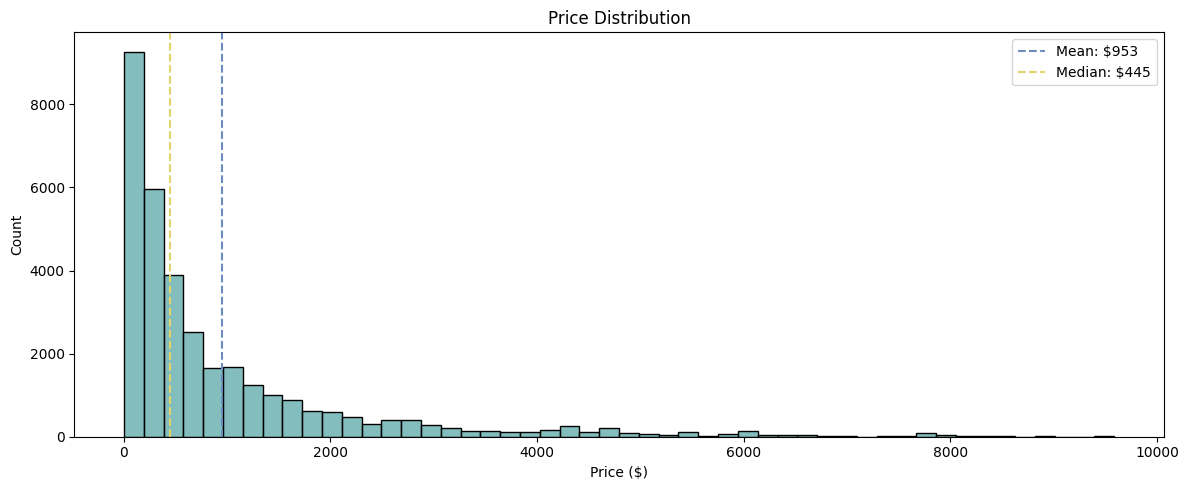

In [ ]:
# Histogram of price distribution
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#5AA7A7", "#96D7C6", "#BAC94A", "#E2D36B", "#6C8CBF"]

sns.histplot(data["price"].dropna(), bins=50, color=colors[0], ax=ax)
ax.axvline(data["price"].mean(), color=colors[4],
           linestyle="--", label=f"Mean: ${data['price'].mean():.0f}")
ax.axvline(data["price"].median(), color=colors[3],
           linestyle="--", label=f"Median: ${data['price'].median():.0f}")
ax.set_title("Price Distribution")
ax.set_xlabel("Price ($)")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()

**Price distribution**

The price distribution is strongly right-skewed.
Most products are bought for below \$1,000, while products with higher price are rarely bought.

The median (\$445) is significantly lower than the mean (\$953), confirming the skew caused by high-value outliers.

### **Global KPIs**

In [ ]:
# Filter only sessions with purchases
orders = data.dropna(subset=["price"]).copy()

# Calculate Financial Metrics

print("GLOBAL BUSINESS METRICS")
print(f"\nTotal Orders:          {orders["session_id"].nunique():,}")
print(f"Total Revenue:         ${data["price"].sum():,.2f}")
print(f"Average Order Value:   ${data["price"].mean():,.2f}")
print(f"Active Countries:      {orders["country"].nunique()}")

GLOBAL BUSINESS METRICS

Total Orders:          33,538
Total Revenue:         $31,971,731.10
Average Order Value:   $953.30
Active Countries:      108


During the period from November 1, 2020 to January 31, 2021, the company completed **33,538 orders**, generating **$31.97M** in total revenue and serving customers in **108 countries**.


In [ ]:
order_month = orders["order_date"].dt.to_period("M")

revenue_by_month = orders.groupby(order_month)["price"].sum().reset_index()
orders_by_month = orders.groupby(order_month)["session_id"].count().reset_index()

revenue_by_month.columns = ["month", "revenue"]
orders_by_month.columns = ["month", "order_count"]

# Convert period to string for plotting
revenue_by_month["month"] = revenue_by_month["month"].astype(str)
orders_by_month["month"] = orders_by_month["month"].astype(str)


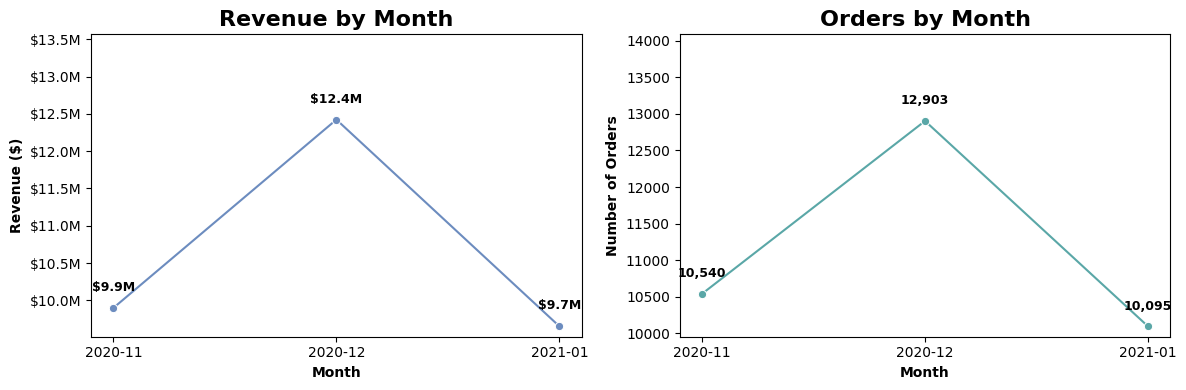

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Revenue by month
sns.lineplot(data=revenue_by_month, x="month", y="revenue",
             color=colors[4], marker="o", ax=axes[0])
axes[0].set_title("Revenue by Month", fontsize=16, fontweight="bold")
axes[0].set_xlabel("Month", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Revenue ($)", fontsize=10, fontweight="bold")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:.1f}M"))
axes[0].set_ylim(bottom=axes[0].get_ylim()[0],
                 top=axes[0].get_ylim()[1] * 1.08)
for i, row in revenue_by_month.iterrows():
    axes[0].annotate(f"${row['revenue']/1e6:.1f}M",
                     xy=(i, row["revenue"]),
                     xytext=(0, 10),
                     textcoords="offset points",
                     ha="center", va="bottom",
                     fontsize=9, fontweight="bold")

# Orders by month
sns.lineplot(data=orders_by_month, x="month", y="order_count",
             color=colors[0], marker="o", ax=axes[1])
axes[1].set_title("Orders by Month", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Month", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Number of Orders", fontsize=10, fontweight="bold")
axes[1].set_ylim(bottom=axes[1].get_ylim()[0],
                 top=axes[1].get_ylim()[1] * 1.08)
for i, row in orders_by_month.iterrows():
    axes[1].annotate(f"{row['order_count']:,}",
                     xy=(i, row["order_count"]),
                     xytext=(0, 10),
                     textcoords="offset points",
                     ha="center", va="bottom",
                     fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

**Monthly Sales Trend**

Both revenue and the number of orders peaked in **December 2020**, reaching **\$12.4M** in revenue and **12,903 orders**. This represents a significant increase compared to November, likely driven by holiday shopping and seasonal promotions.

In **January 2021**, both metrics declined to **\$9.7M** in revenue and **10,095 orders**, returning to levels close to those observed in November.

Overall, the strong correlation between revenue and order volume suggests that the revenue growth in December was primarily driven by an increase in the number of purchases rather than a significant change in average order value.

### **Sales by Continent and Country**





In [ ]:
# Top 3 Continents by Total Sales
continent_sales = (orders.groupby("continent")["price"]
                   .sum()
                   .sort_values(ascending=False)
                   .reset_index())
continent_sales.columns = ["continent", "total_sales"]
continent_sales["total_sales"] = continent_sales["total_sales"].round(2)
continent_sales["share_%"] = (continent_sales["total_sales"] /
                               continent_sales["total_sales"].sum() * 100).round(2)
print("Top 3 Continents by Total Sales:")
print(continent_sales.head(3).to_string(index=False))

# Top 3 Continents by Order Count
continent_orders = (orders.groupby("continent")["session_id"]
                    .count()
                    .sort_values(ascending=False)
                    .reset_index())
continent_orders.columns = ["continent", "order_count"]
print("\nTop 3 Continents by Order Count:")
print(continent_orders.head(3).to_string(index=False))

Top 3 Continents by Total Sales:
continent  total_sales  share_%
 Americas   17665280.0    55.25
     Asia    7601298.3    23.78
   Europe    5934624.2    18.56

Top 3 Continents by Order Count:
continent  order_count
 Americas        18553
     Asia         7950
   Europe         6261


In [ ]:
# Top 5 Countries by Total Sales
country_sales = (orders.groupby("country")["price"]
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index())
country_sales.columns = ["country", "total_sales"]
country_sales["total_sales"] = country_sales["total_sales"].round(2)
country_sales["share_%"] = (country_sales["total_sales"] /
                             country_sales["total_sales"].sum() * 100).round(2)
print("Top 5 Countries by Total Sales:")
print(country_sales.head(5).to_string(index=False))

# Top 5 Countries by Order Count
country_orders = (orders.groupby("country")["session_id"]
                  .count()
                  .sort_values(ascending=False)
                  .reset_index())
country_orders.columns = ["country", "order_count"]
print("\nTop 5 Countries by Order Count:")
print(country_orders.head(5).to_string(index=False))

Top 5 Countries by Total Sales:
       country  total_sales  share_%
 United States   13943553.9    43.61
         India    2809762.0     8.79
        Canada    2437921.0     7.63
United Kingdom     938317.9     2.93
        France     710692.8     2.22

Top 5 Countries by Order Count:
       country  order_count
 United States        14673
         India         3029
        Canada         2560
United Kingdom         1029
        France          678


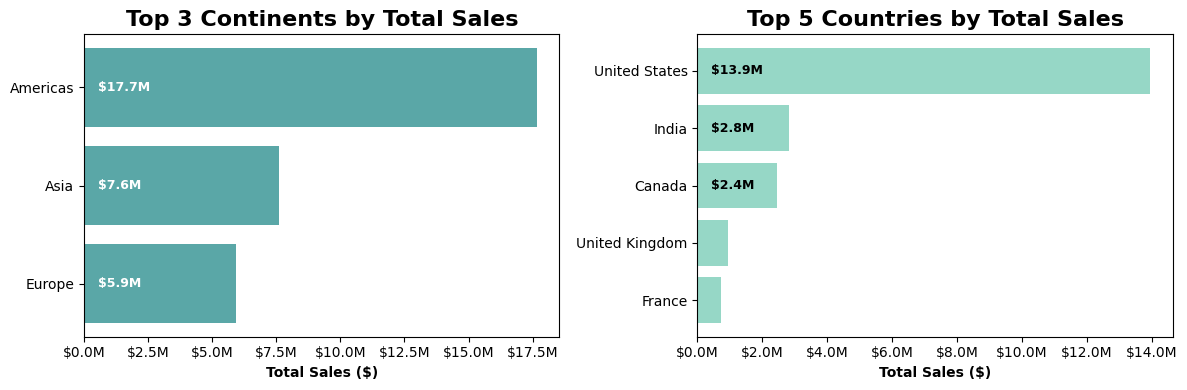

In [ ]:
#Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Top 3 Continents by Sales
continent_data = continent_sales.head(3)
continent_bars = axes[0].barh(continent_data["continent"], continent_data["total_sales"], color=colors[0])
axes[0].set_title("Top 3 Continents by Total Sales", fontsize=16, fontweight="bold")
axes[0].set_xlabel("Total Sales ($)", fontsize=10, fontweight="bold")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.1f}M"))
axes[0].invert_yaxis()

for bar in continent_bars:
    value = bar.get_width()
    axes[0].annotate(f"${value/1e6:.1f}M",
     (0, bar.get_y() + bar.get_height()/2),
                     xytext=(10, 0), textcoords="offset points",
                     va="center", ha="left",
                     fontsize=9, fontweight="bold", color="white")

# Top 5 Countries by Sales
country_data = country_sales.head(5)
country_bars = axes[1].barh(country_data["country"], country_data["total_sales"], color=colors[1])
axes[1].set_title("Top 5 Countries by Total Sales", fontsize=16, fontweight="bold")
axes[1].set_xlabel("Total Sales ($)", fontsize=10, fontweight="bold")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:,.1f}M"))
axes[1].invert_yaxis()

for bar in country_bars[:3]:
    value = bar.get_width()
    axes[1].annotate(f"${value/1e6:.1f}M",
     (0, bar.get_y() + bar.get_height()/2),
                     xytext=(10, 0), textcoords="offset points",
                     va="center", ha="left",
                     fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

**Sales by Continent and Country**

Sales are strongly concentrated in the **Americas**, which generate **55.25%** of total revenue, followed by **Asia (23.78%)** and **Europe (18.56%)**. The distribution of orders closely matches the revenue structure, indicating that higher revenue is mainly driven by a larger number of purchases.

At the country level, the **United States** dominates sales, accounting for **43.61%** of total revenue and 14,673 orders, making it the company’s primary market. **India** and **Canada** rank second and third, contributing 8.79% and 7.63% of revenue respectively.

Overall, sales are heavily concentrated in a few key markets, particularly the United States, while other regions represent potential growth opportunities.

### **Sales by Product Categories**

In [ ]:
# Top 10 Product Categories by Total Sales
category_sales = (orders.groupby("category")["price"]
                  .sum()
                  .sort_values(ascending=False)
                  .reset_index())
category_sales.columns = ["category", "total_sales"]
category_sales["share_%"] = (category_sales["total_sales"] /
                              category_sales["total_sales"].sum() * 100).round(2)

print("Top 10 Categories by Total Sales:")
print(category_sales.head(10).to_string(index=False))

Top 10 Categories by Total Sales:
                        category  total_sales  share_%
               Sofas & armchairs    8388254.5    26.24
                          Chairs    6147748.8    19.23
                            Beds    4919725.0    15.39
      Bookcases & shelving units    3640818.1    11.39
            Cabinets & cupboards    2336499.5     7.31
               Outdoor furniture    2142222.2     6.70
                  Tables & desks    1790307.5     5.60
Chests of drawers & drawer units     906562.5     2.84
                   Bar furniture     735503.0     2.30
            Children's furniture     467697.0     1.46


In [ ]:
top3_share = category_sales.head(3)["share_%"].sum()
print(f"Top 3 categories share: {top3_share:.2f}%")

Top 3 categories share: 60.86%


In [ ]:
# Top 10 Categories in the USA (top country)
usa_orders = orders[orders["country"] == "United States"]

usa_category_sales = (usa_orders.groupby("category")["price"]
                      .sum()
                      .sort_values(ascending=False)
                      .reset_index())
usa_category_sales.columns = ["category", "total_sales"]
usa_category_sales["share_%"] = (usa_category_sales["total_sales"] /
                                  usa_category_sales["total_sales"].sum() * 100).round(2)

print("Top 10 Categories in the United States:")
print(usa_category_sales.head(10).to_string(index=False))

Top 10 Categories in the United States:
                        category  total_sales  share_%
               Sofas & armchairs    3707144.5    26.59
                          Chairs    2619773.8    18.79
                            Beds    2213058.0    15.87
      Bookcases & shelving units    1567606.9    11.24
            Cabinets & cupboards     994545.5     7.13
               Outdoor furniture     929245.2     6.66
                  Tables & desks     777865.0     5.58
Chests of drawers & drawer units     382388.0     2.74
                   Bar furniture     330805.0     2.37
            Children's furniture     207575.0     1.49


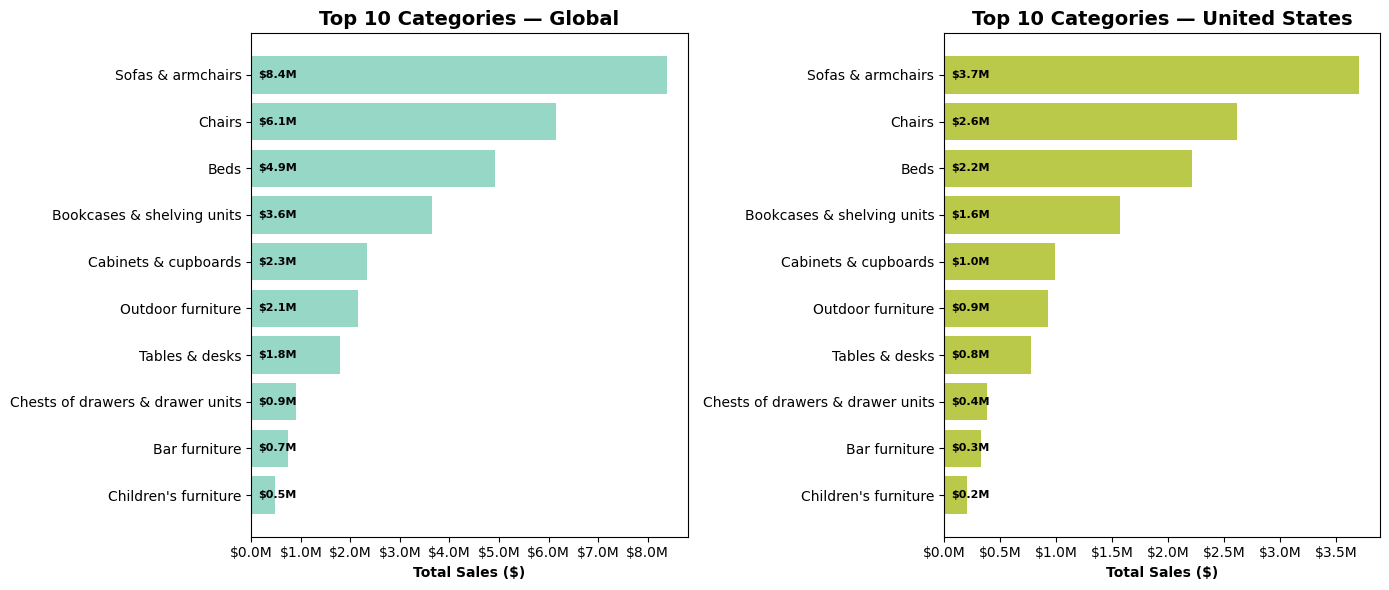

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Global top 10
top10_global = category_sales.head(10).sort_values("total_sales")
bars0 = axes[0].barh(top10_global["category"], top10_global["total_sales"], color=colors[1])
axes[0].set_title("Top 10 Categories — Global", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Total Sales ($)", fontsize=10, fontweight="bold")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:.1f}M"))

for bar in bars0:
    value = bar.get_width()
    axes[0].annotate(f"${value/1e6:.1f}M",
                     (0, bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     va="center", ha="left",
                     fontsize=8, fontweight="bold")

# USA top 10
top10_usa = usa_category_sales.head(10).sort_values("total_sales")
bars1 = axes[1].barh(top10_usa["category"], top10_usa["total_sales"], color=colors[2])
axes[1].set_title("Top 10 Categories — United States", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Total Sales ($)", fontsize=10, fontweight="bold")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:.1f}M"))

for bar in bars1:
    value = bar.get_width()
    axes[1].annotate(f"${value/1e6:.1f}M",
                     (0, bar.get_y() + bar.get_height() / 2),
                     xytext=(5, 0), textcoords="offset points",
                     va="center", ha="left",
                     fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

**Sales by Product Categories**

The top 3 categories dominate total revenue:
- **Sofas & armchairs** lead with \$8.4M (26.24% of total sales)
- **Chairs** follow with \$6.1M (19.23%)
- **Beds** rank third with \$4.9M (15.39%)

Together, the top 3 categories account for **60.86%** of all revenue,
indicating a strong concentration in seating and sleeping furniture.

The category ranking in the United States is identical to the global ranking. The share percentages are also very similar, with differences of less than 1% for each category.

### **Sales by Device Type & Traffic Channel**

In [ ]:
# Sales by Device Type
device_sales = (orders.groupby("device")["price"]
                .sum()
                .sort_values(ascending=False)
                .reset_index())
device_sales.columns = ["device", "total_sales"]
device_sales["share_%"] = (device_sales["total_sales"] /
                            device_sales["total_sales"].sum() * 100).round(2)

print("Sales by Device Type:")
print(device_sales.to_string(index=False))

Sales by Device Type:
 device  total_sales  share_%
desktop   18864039.0    59.00
 mobile   12384225.8    38.73
 tablet     723466.3     2.26


In [ ]:
# Top 10 Mobile Models by Sales
mobile_sales = (orders[orders["device"] == "mobile"]
                .groupby("mobile_model_name")["price"]
                .sum()
                .sort_values(ascending=False)
                .reset_index())
mobile_sales.columns = ["model", "total_sales"]
mobile_sales["share_%"] = (mobile_sales["total_sales"] /
                            mobile_sales["total_sales"].sum() * 100).round(2)

print("Top 10 Mobile Models by Sales:")
print(mobile_sales.head(10).to_string(index=False))

Top 10 Mobile Models by Sales:
     model  total_sales  share_%
    iPhone    6420776.3    51.85
   <Other>    5735073.6    46.31
Pixel 4 XL     118287.7     0.96
   Pixel 3     109148.2     0.88
    Safari        595.0     0.00
      Edge        345.0     0.00


**Note on mobile model analysis:** The mobile_model_name column contains
a large share of unidentified values (Other — 46.31%) and browser names (Safari, Edge), indicating incomplete device tracking data.
Therefore, mobile model analysis is excluded from this report.
Instead, device-type analysis (desktop/mobile/tablet) provides
more reliable insights.

In [ ]:
# Sales by Traffic Channel
traffic_sales = (orders.groupby("traffic_channel")["price"]
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index())
traffic_sales.columns = ["channel", "total_sales"]
traffic_sales["share_%"] = (traffic_sales["total_sales"] /
                             traffic_sales["total_sales"].sum() * 100).round(2)

print("Sales by Traffic Channel:")
print(traffic_sales.to_string(index=False))

Sales by Traffic Channel:
       channel  total_sales  share_%
Organic Search   11433151.6    35.76
   Paid Search    8511049.4    26.62
        Direct    7494923.4    23.44
 Social Search    2532105.7     7.92
     Undefined    2000501.0     6.26


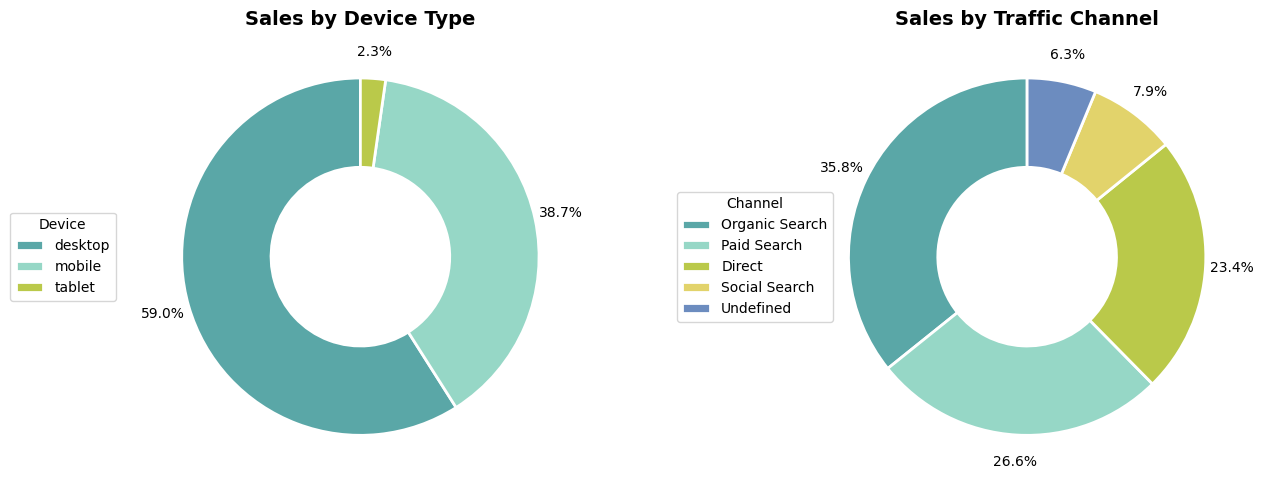

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Device
awedges0, texts0, autotexts0 = axes[0].pie(
    device_sales["total_sales"],
    labels=None,
    autopct="%1.1f%%",
    colors=colors[:len(device_sales)],
    startangle=90,
    pctdistance=1.15,
    wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2})
axes[0].legend(awedges0, device_sales["device"],
               title="Device", loc="center left",
               bbox_to_anchor=(-0.3, 0.5))
axes[0].set_title("Sales by Device Type", fontsize=14, fontweight="bold")

# Traffic Channel
wedges1, texts1, autotexts1 = axes[1].pie(
    traffic_sales["total_sales"],
    labels=None,
    autopct="%1.1f%%",
    colors=colors[:len(traffic_sales)],
    startangle=90,
    pctdistance=1.15,
    wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 2})
axes[1].legend(wedges1, traffic_sales["channel"],
               title="Channel", loc="center left",
               bbox_to_anchor=(-0.3, 0.5))
axes[1].set_title("Sales by Traffic Channel", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

**Sales by Device Type & Traffic Channel**

**Device Type**

Desktop dominates with **59.0%** of total sales, followed by mobile (38.7%) and tablet (2.3%). Despite the growing trend of mobile shopping, desktop remains the primary purchase device — likely because furniture is a high-consideration purchase where users prefer larger screens for browsing.

**Traffic Channel**

Organic Search leads with **35.76%** of sales, followed by Paid Search (26.62%) and Direct traffic (23.44%). Social Search contributes 7.92%, while Undefined traffic (6.26%) likely represents sessions where UTM parameters were not properly configured.

The strong organic search performance suggests good SEO visibility,
while the significant paid search share indicates active investment
in search advertising.

### **Registered Users Analysis**

In [ ]:
# Registered Users Analysis
registered = data[data["account_id"].notna()].copy()

# Email verification rate
email_verified_pct = (registered["email_verified"].sum() /
                      len(registered) * 100).round(2)
print(f"Email verified: {email_verified_pct}%")

# Unsubscribe rate
unsubscribed_pct = (registered["is_unsubscribed"].sum() /
                    len(registered) * 100).round(2)
print(f"Unsubscribed: {unsubscribed_pct}%")

# Top 10 countries by registered users
registered_countries = (registered.groupby("country")["account_id"]
                        .nunique()
                        .sort_values(ascending=False)
                        .reset_index())
registered_countries.columns = ["country", "registered_users"]
print("\nTop 10 Countries by Registered Users:")
print(registered_countries.head(10).to_string(index=False))

Email verified: 71.7%
Unsubscribed: 16.94%

Top 10 Countries by Registered Users:
       country  registered_users
 United States             12384
         India              2687
        Canada              2067
United Kingdom               859
        France               553
         Spain               536
        Taiwan               500
         China               490
       Germany               490
         Italy               386


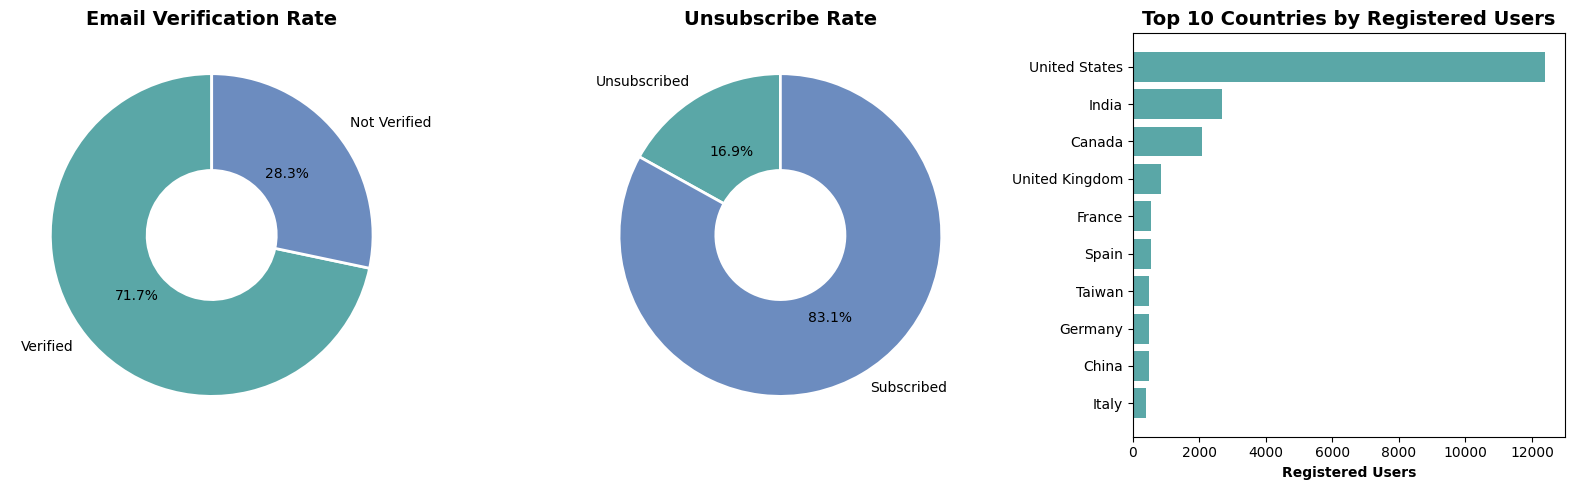

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Email verification
email_data = [email_verified_pct, 100 - email_verified_pct]
axes[0].pie(email_data, labels=["Verified", "Not Verified"],
            autopct="%1.1f%%", colors=[colors[0], colors[4]],
            startangle=90,
            wedgeprops={"width": 0.6, "edgecolor": "white", "linewidth": 2})
axes[0].set_title("Email Verification Rate", fontsize=14, fontweight="bold")

# Unsubscribe rate
unsub_data = [unsubscribed_pct, 100 - unsubscribed_pct]
axes[1].pie(unsub_data, labels=["Unsubscribed", "Subscribed"],
            autopct="%1.1f%%", colors=[colors[0], colors[4]],
            startangle=90,
            wedgeprops={"width": 0.6, "edgecolor": "white", "linewidth": 2})
axes[1].set_title("Unsubscribe Rate", fontsize=14, fontweight="bold")

# Top 10 countries
top10_reg = registered_countries.head(10).sort_values("registered_users")
axes[2].barh(top10_reg["country"], top10_reg["registered_users"], color=colors[0])
axes[2].set_title("Top 10 Countries by Registered Users", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Registered Users", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In [ ]:
# Subscribed vs Unsubscribed Sales Behavior
subscribed_orders = orders[orders["is_unsubscribed"] == False]
unsubscribed_orders = orders[orders["is_unsubscribed"] == True]

print("Subscribed users:")
print(f"  Orders:          {len(subscribed_orders):,}")
print(f"  Total Sales:     ${subscribed_orders['price'].sum():,.2f}")
print(f"  Avg Order Value: ${subscribed_orders['price'].mean():,.2f}")

print("\nUnsubscribed users:")
print(f"  Orders:          {len(unsubscribed_orders):,}")
print(f"  Total Sales:     ${unsubscribed_orders['price'].sum():,.2f}")
print(f"  Avg Order Value: ${unsubscribed_orders['price'].mean():,.2f}")

Subscribed users:
  Orders:          2,334
  Total Sales:     $2,150,796.90
  Avg Order Value: $921.51

Unsubscribed users:
  Orders:          447
  Total Sales:     $431,721.60
  Avg Order Value: $965.82


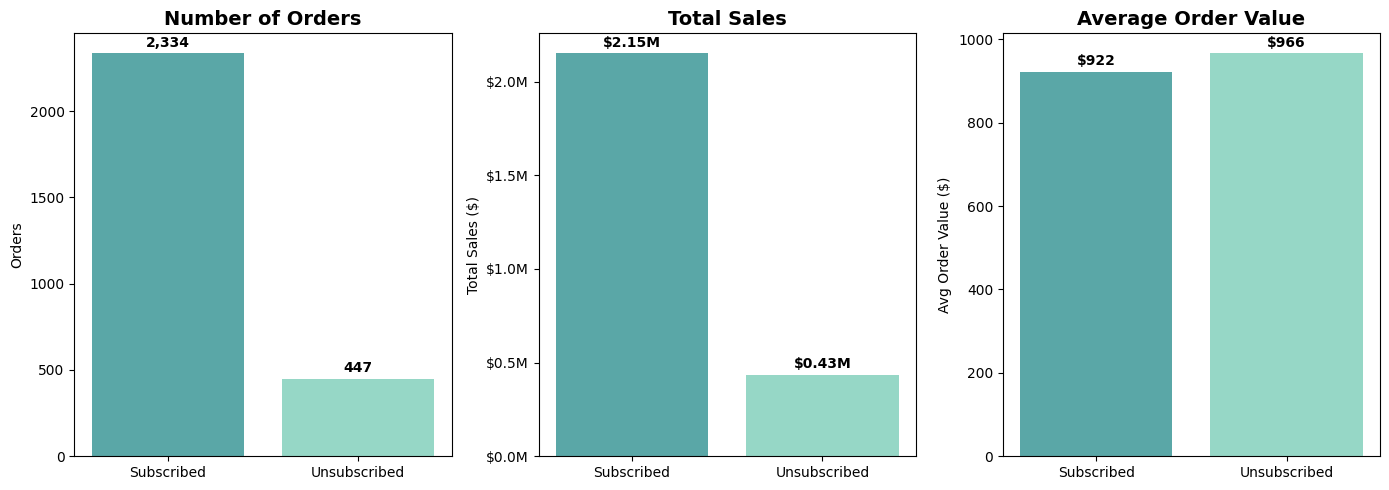

In [ ]:
# Visualization
sub_comparison = pd.DataFrame({
    "group": ["Subscribed", "Unsubscribed"],
    "orders": [len(subscribed_orders), len(unsubscribed_orders)],
    "total_sales": [subscribed_orders["price"].sum(), unsubscribed_orders["price"].sum()],
    "avg_order_value": [subscribed_orders["price"].mean(), unsubscribed_orders["price"].mean()]
})

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Orders count
bars0 = axes[0].bar(sub_comparison["group"], sub_comparison["orders"],
                    color=colors[:2])
axes[0].set_title("Number of Orders", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Orders")
for bar in bars0:
    axes[0].annotate(f"{bar.get_height():,}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 5), textcoords="offset points",
                     ha="center", fontweight="bold", fontsize=10)

# Total sales
bars1 = axes[1].bar(sub_comparison["group"], sub_comparison["total_sales"],
                    color=colors[:2])
axes[1].set_title("Total Sales", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Total Sales ($)")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:.1f}M"))
for bar in bars1:
    axes[1].annotate(f"${bar.get_height()/1e6:.2f}M",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 5), textcoords="offset points",
                     ha="center", fontweight="bold", fontsize=10)

# Avg order value
bars2 = axes[2].bar(sub_comparison["group"], sub_comparison["avg_order_value"],
                    color=colors[:2])
axes[2].set_title("Average Order Value", fontsize=14, fontweight="bold")
axes[2].set_ylabel("Avg Order Value ($)")
for bar in bars2:
    axes[2].annotate(f"${bar.get_height():.0f}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 5), textcoords="offset points",
                     ha="center", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

**Registered Users Analysis**

**Email Verification**

**71.7%** of registered users confirmed their email address — a healthy verification rate, suggesting most users who register are genuinely engaged.

**Unsubscribe Rate**

Only **16.94%** of registered users unsubscribed from the mailing list, meaning **83.06%** remain subscribed — a strong retention signal for email marketing.

**Subscribed vs Unsubscribed Behavior**

Subscribed users generated significantly more orders (2,334 vs 447) and higher total sales (\$2.15M vs 431K), which is expected given their larger share.

However, the average order value is slightly higher for unsubscribed users (\$965 vs \$921), suggesting that users who opted out still make higher-value purchases when they do buy — they may simply prefer not to receive promotional emails.

**Top Countries by Registered Users**

The geographic distribution of registered users mirrors the overall sales ranking — the United States leads with 12,384 registered users, followed by India (2,687) and Canada (2,067).

## **5. Business Analysis**


### **Conversion Funnel**

In [ ]:
# Conversion Funnel
total_sessions = data["session_id"].nunique()
registered_sessions = data[data["account_id"].notna()]["session_id"].nunique()
sessions_with_purchase = orders["session_id"].nunique()
registered_with_purchase = orders[orders["account_id"].notna()]["session_id"].nunique()

funnel = pd.DataFrame({
    "stage": ["All Sessions", "Registered Users", "Sessions with Purchase", "Registered + Purchase"],
    "count": [total_sessions, registered_sessions, sessions_with_purchase, registered_with_purchase]
})
funnel["share_%"] = (funnel["count"] / total_sessions * 100).round(2)
print(funnel.to_string(index=False))

                 stage  count  share_%
          All Sessions 349545   100.00
      Registered Users  27945     7.99
Sessions with Purchase  33538     9.59
 Registered + Purchase   2781     0.80


In [ ]:
reg_conversion = (registered_with_purchase / registered_sessions * 100)
guest_sessions = total_sessions - registered_sessions
guest_with_purchase = sessions_with_purchase - registered_with_purchase
guest_conversion = (guest_with_purchase / guest_sessions * 100)

print(f"Registered users conversion rate: {reg_conversion:.2f}%")
print(f"Guest users conversion rate:      {guest_conversion:.2f}%")

Registered users conversion rate: 9.95%
Guest users conversion rate:      9.56%


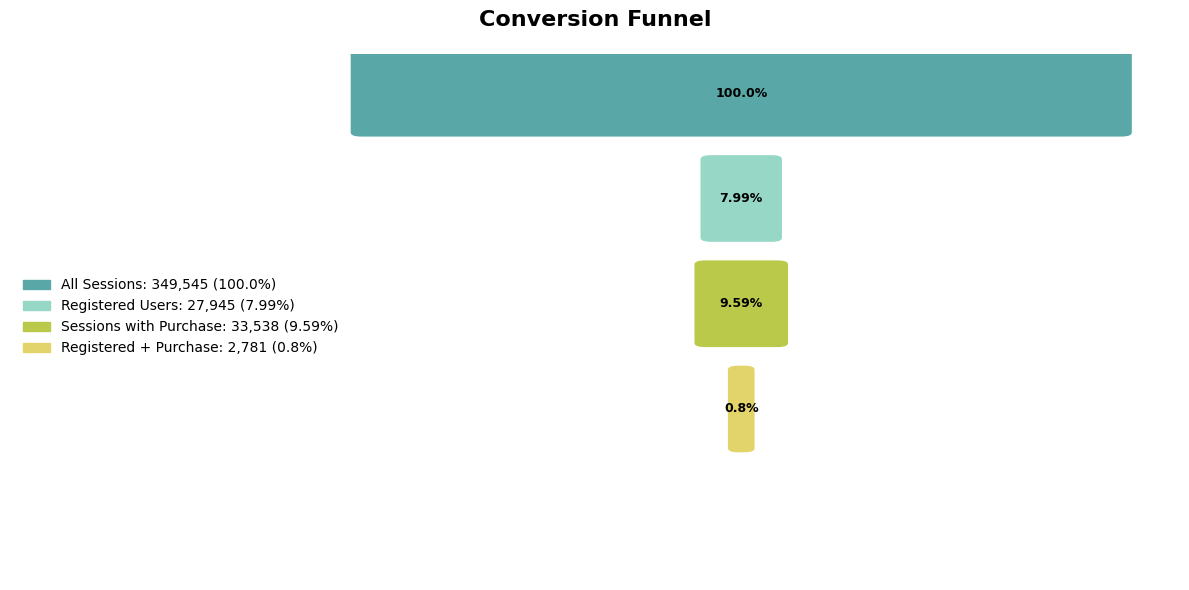

In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

stages = funnel["stage"].tolist()
values = funnel["count"].tolist()
shares = funnel["share_%"].tolist()

max_width = 0.65
bar_height = 0.15
gap = 0.05

patches = []
for i, (stage, value, share) in enumerate(zip(stages, values, shares)):
    width = max_width * value / values[0]
    y = 1 - i * (bar_height + gap)
    rect = mpatches.FancyBboxPatch(
        (0.3 + (max_width - width) / 2, y - bar_height),
        width, bar_height,
        boxstyle="round,pad=0.01",
        facecolor=colors[i], edgecolor="white", linewidth=2)
    ax.add_patch(rect)
    ax.text(0.3 + max_width / 2, y - bar_height / 2,
            f"{share}%",
            ha="center", va="center",
            fontsize=9, fontweight="bold")
    patches.append(mpatches.Patch(color=colors[i],
                                  label=f"{stage}: {value:,} ({share}%)"))

ax.legend(handles=patches, loc="center left",
          bbox_to_anchor=(0.0, 0.5),
          fontsize=10, frameon=False)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Conversion Funnel", fontsize=16, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

**Conversion Funnel Analysis**

Out of 349,545 total sessions, only **9.59%** resulted in a purchase
and just **7.99%** belonged to registered users.

**Key Finding: Registered vs Guest Conversion**
- Registered users conversion rate: **9.95%**
- Guest users conversion rate: **9.56%**

The conversion rates are nearly identical, with registered users converting only slightly more (0.39 percentage points higher).

This suggests that **account registration does not significantly drive purchase behavior** — users buy regardless of whether they have an account. This could indicate that the registration process is not effectively tied to purchase incentives (e.g., no exclusive discounts or loyalty rewards for registered users).

### **Revenue Concentration (Pareto)**

In [ ]:
# Revenue Concentration (Pareto)
country_rev = (orders.groupby("country")["price"]
               .sum()
               .sort_values(ascending=False)
               .reset_index())
country_rev.columns = ["country", "revenue"]
country_rev["cumulative_%"] = (country_rev["revenue"].cumsum() /
                                country_rev["revenue"].sum() * 100).round(2)

pareto_80 = country_rev[country_rev["cumulative_%"] <= 80]
print(f"\nCountries generating 80% of revenue: {len(pareto_80)}")
print(f"Total countries: {len(country_rev)}")
print(f"Pareto ratio: {len(pareto_80)/len(country_rev)*100:.1f}% of countries = 80% of revenue")
print(country_rev.head(15).to_string(index=False))


Countries generating 80% of revenue: 15
Total countries: 108
Pareto ratio: 13.9% of countries = 80% of revenue
       country    revenue  cumulative_%
 United States 13943553.9         43.61
         India  2809762.0         52.40
        Canada  2437921.0         60.03
United Kingdom   938317.9         62.96
        France   710692.8         65.18
         Spain   631546.7         67.16
       Germany   599221.4         69.03
         China   588329.6         70.87
        Taiwan   552710.3         72.60
     Singapore   456447.2         74.03
         Japan   417509.1         75.34
   South Korea   413158.2         76.63
         Italy   396242.1         77.87
        Brazil   339001.8         78.93
        Poland   318114.0         79.92


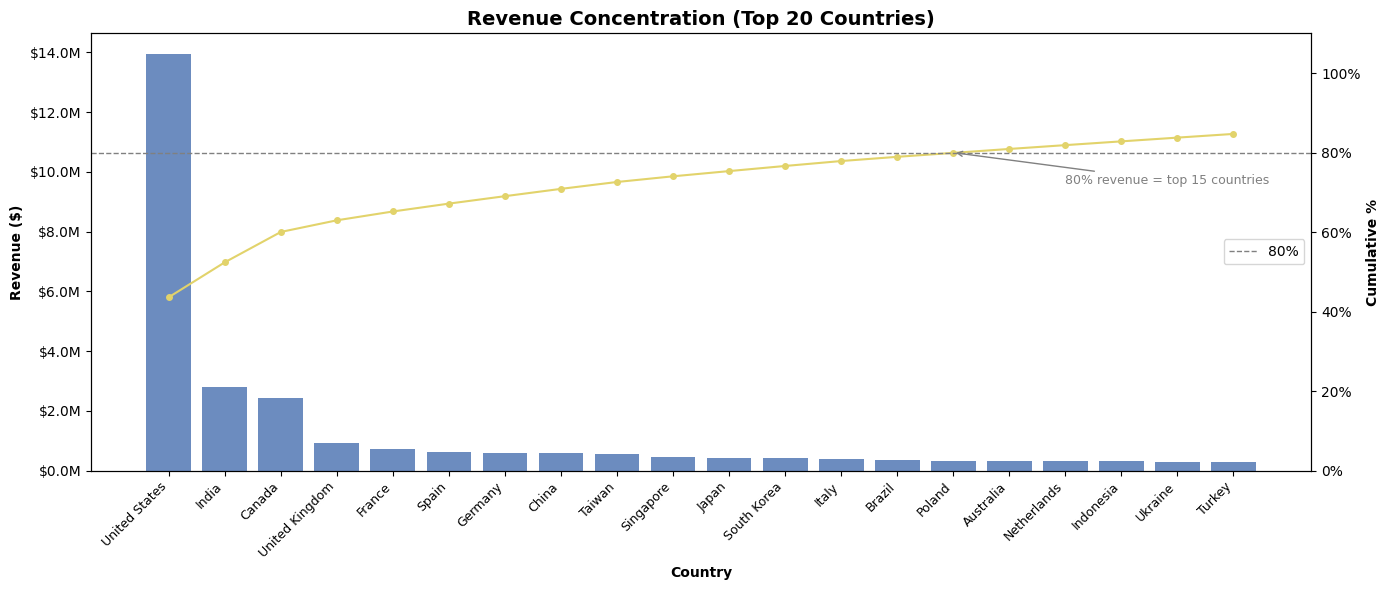

In [ ]:
# Visualization
fig, ax1 = plt.subplots(figsize=(14, 6))

top20 = country_rev.head(20)
x = range(len(top20))

ax2 = ax1.twinx()
ax1.bar(x, top20["revenue"], color=colors[4])
ax2.plot(x, top20["cumulative_%"],
         color=colors[3], marker="o", markersize=4)
ax2.axhline(y=80, color="gray", linestyle="--", linewidth=1, label="80%")

ax1.set_title("Revenue Concentration (Top 20 Countries)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Country", fontsize=10, fontweight="bold")
ax1.set_ylabel("Revenue ($)", fontsize=10, fontweight="bold")
ax2.set_ylabel("Cumulative %", fontsize=10, fontweight="bold")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e6:.1f}M"))

ax1.set_xticks(x)
ax1.set_xticklabels(top20["country"], rotation=45, ha="right", fontsize=9)
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"{x:.0f}%"))
ax2.legend(loc="center right")

ax2.annotate(f"80% revenue = top {len(pareto_80)} countries",
             xy=(len(pareto_80) - 1, 80),
             xytext=(len(pareto_80) + 1, 72),
             fontsize=9, color="gray",
             arrowprops=dict(arrowstyle="->", color="gray"))

plt.tight_layout()
plt.show()

**Revenue Concentration (Pareto Analysis)**

The revenue distribution is highly concentrated:
- **13.9% of countries** (15 out of 108) generate **80% of total revenue**
- The **United States alone** accounts for **43.61%** of all revenue — nearly as much as the next 14 countries combined

This is a more extreme concentration than the classic 80/20 Pareto rule, suggesting the business is heavily dependent on a single market.

**Top 15 countries generating 80% of revenue:**
1. United States - \$13.9M
2. India - \$2.8M
3. Canada - \$2.4M
4. United Kingdom - \$0.9M
5. France - \$0.7M
6. Spain - \$0.6M
7. Germany - \$0.6M
8. China - \$0.6M
9. Taiwan - \$0.6M
10. Singapore - \$0.5M
11. Japan - \$0.4M
12. South Korea - \$0.4M
13. Italy - \$0.4M
14. Brazil - \$0.3M
15. Poland - \$0.3M

**Key Risk:** Heavy reliance on the US market creates geographic concentration risk. India and Canada show strong potential as secondary markets worth investing in.

### **Category Performance by Device**

In [ ]:
# Category Performance by Device
cat_device = (orders.groupby(["category", "device"])["price"]
              .sum()
              .reset_index())
cat_device_pivot = cat_device.pivot(index="category", columns="device", values="price").fillna(0)

# Keep top 10 categories
top10_cats = category_sales.head(10)["category"].tolist()
cat_device_pivot = cat_device_pivot.loc[cat_device_pivot.index.isin(top10_cats)]
cat_device_pivot = cat_device_pivot.div(cat_device_pivot.sum(axis=1), axis=0) * 100
cat_device_pivot = cat_device_pivot.sort_values("desktop", ascending=False)

print(cat_device_pivot.round(2))

device                            desktop  mobile  tablet
category                                                 
Chairs                              60.75   36.61    2.64
Children's furniture                60.65   37.16    2.19
Tables & desks                      59.61   38.14    2.25
Chests of drawers & drawer units    59.31   38.70    1.99
Cabinets & cupboards                59.12   38.26    2.62
Bar furniture                       58.74   39.19    2.06
Bookcases & shelving units          58.49   39.47    2.03
Sofas & armchairs                   58.28   39.46    2.26
Outdoor furniture                   58.28   39.53    2.20
Beds                                58.25   39.82    1.93


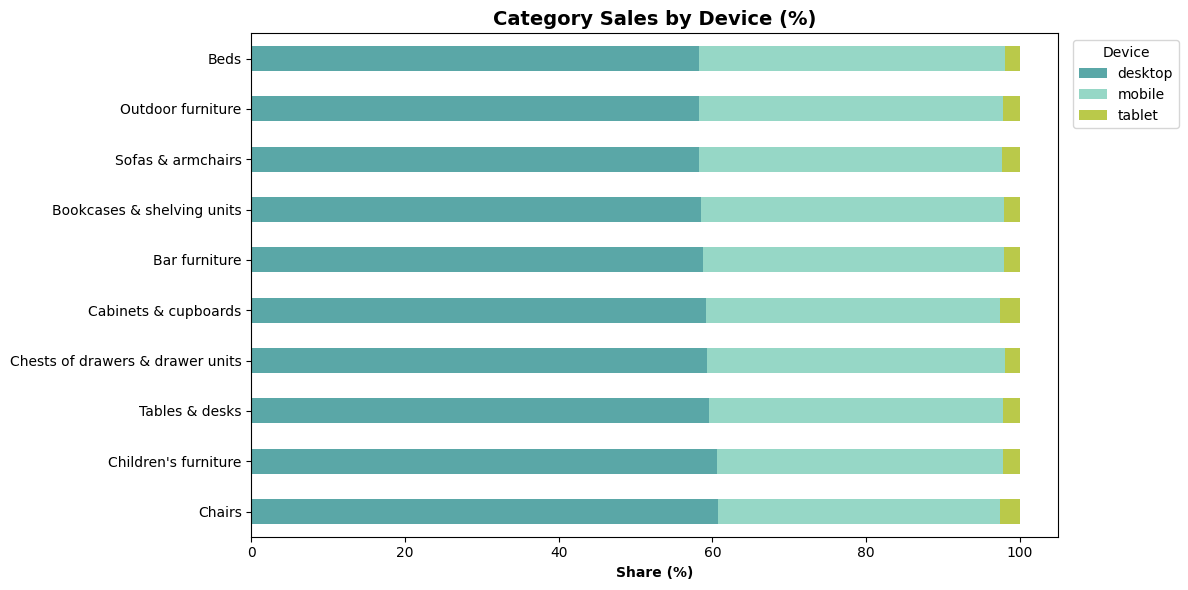

In [ ]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

cat_device_pivot.plot(kind="barh", stacked=True, ax=ax, color=colors[:3])
ax.set_title("Category Sales by Device (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("Share (%)", fontsize=10, fontweight="bold")
ax.set_ylabel("")
ax.legend(title="Device", bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
# Share of each category within each device
device_total = orders.groupby("device")["price"].sum()
cat_device["device_share"] = cat_device.apply(
    lambda row: row["price"] / device_total[row["device"]] * 100, axis=1).round(2)

# Compare mobile vs desktop share
mobile_share = cat_device[cat_device["device"] == "mobile"][["category", "device_share"]].rename(columns={"device_share": "mobile_%"})
desktop_share = cat_device[cat_device["device"] == "desktop"][["category", "device_share"]].rename(columns={"device_share": "desktop_%"})

comparison = mobile_share.merge(desktop_share, on="category")
comparison["mobile_vs_desktop"] = (comparison["mobile_%"] - comparison["desktop_%"]).round(2)
comparison = comparison.sort_values("mobile_vs_desktop", ascending=False)

print("Categories more popular on mobile vs desktop:")
print(comparison.to_string(index=False))

Categories more popular on mobile vs desktop:
                            category  mobile_%  desktop_%  mobile_vs_desktop
                   Sofas & armchairs     26.73      25.91               0.82
                                Beds     15.82      15.19               0.63
          Bookcases & shelving units     11.60      11.29               0.31
                   Outdoor furniture      6.84       6.62               0.22
                       Bar furniture      2.33       2.29               0.04
                       Room dividers      0.29       0.28               0.01
Sideboards, buffets & console tables      0.40       0.39               0.01
                      Café furniture      0.43       0.44              -0.01
    Chests of drawers & drawer units      2.83       2.85              -0.02
                   Nursery furniture      0.42       0.46              -0.04
                Children's furniture      1.40       1.50              -0.10
                Cabinets & cup

**Category Performance by Device**

The device-level analysis reveals that purchasing behavior is **remarkably consistent across all device types**.

The maximum difference between mobile and desktop share is only **1.63%**, suggesting that:
- Product categories do not drive device preference
- Users are equally comfortable purchasing any furniture category
  on mobile or desktop
- The store likely has a well-optimized mobile experience

Given the negligible differences, device type is not a meaningful segmentation variable for category analysis in this dataset.

## **6. Time Series Analysis**


### **Daily Revenue Trend**

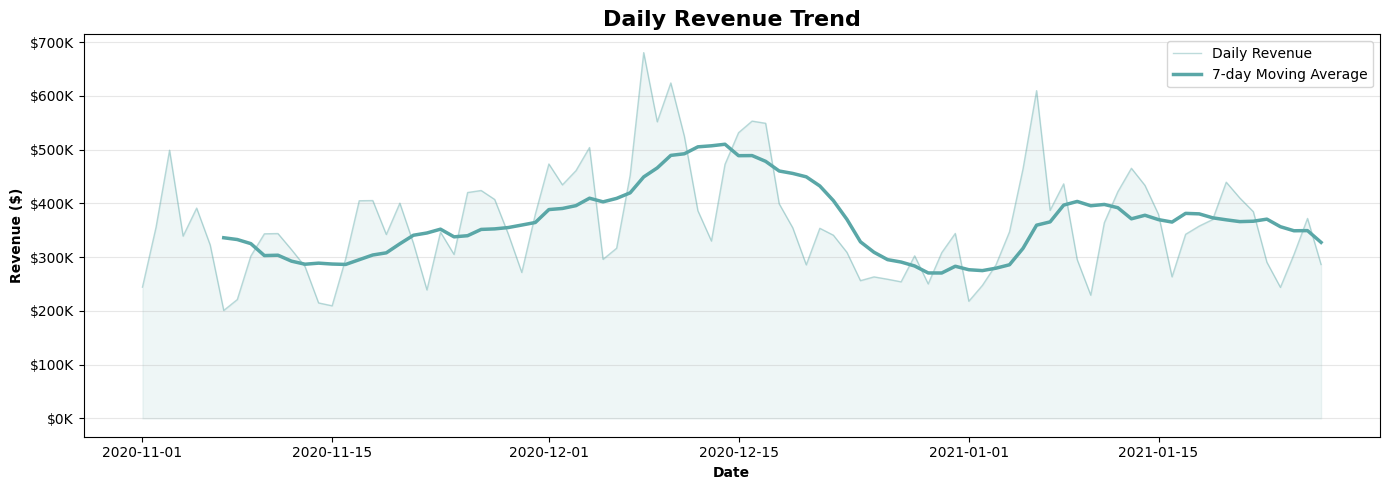

In [ ]:
# Daily Sales
daily_sales = (orders.groupby("order_date")["price"]
               .sum()
               .reset_index())
daily_sales.columns = ["date", "revenue"]

# Visualization
fig, ax = plt.subplots(figsize=(14, 5))

daily_sales["revenue_7d"] = daily_sales["revenue"].rolling(7).mean()

ax.plot(daily_sales["date"], daily_sales["revenue"],
        color=colors[0], linewidth=1, alpha=0.4, label="Daily Revenue")
ax.plot(daily_sales["date"], daily_sales["revenue_7d"],
        color=colors[0], linewidth=2.5, label="7-day Moving Average")
ax.fill_between(daily_sales["date"], daily_sales["revenue"], alpha=0.1, color=colors[0])

ax.set_title("Daily Revenue Trend", fontsize=16, fontweight="bold")
ax.set_xlabel("Date", fontsize=10, fontweight="bold")
ax.set_ylabel("Revenue ($)", fontsize=10, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e3:.0f}K"))
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Daily Revenue Trend**

The 7-day moving average reveals a clear pattern:
- Revenue gradually increased throughout November, reaching a peak around **December 10-15** (~\$500K/day)
- A sharp decline after mid-December likely marks the end of the holiday shopping season
- Revenue stabilized in January at ~\$350-400K/day

**Seasonality**
With only 91 days of data it is not possible to confirm long-term seasonality, however the December peak is consistent with holiday shopping behavior (Black Friday, Cyber Monday, Christmas).

The spike on **~November 2** (\$500K) and **~December 10** (\$680K — highest single day) likely correspond to promotional events or sales campaigns.

### **Revenue Dynamics by Segment**

In [ ]:
# Sales by Continent
continent_daily = (orders[orders["continent"].isin(["Americas", "Asia", "Europe"])]
                   .groupby(["order_date", "continent"])["price"]
                   .sum()
                   .reset_index())
continent_daily.columns = ["date", "continent", "revenue"]

# Sales by Traffic Channel
channel_daily = (orders.groupby(["order_date", "traffic_channel"])["price"]
                 .sum()
                 .reset_index())
channel_daily.columns = ["date", "channel", "revenue"]

# Sales by Device
device_daily = (orders.groupby(["order_date", "device"])["price"]
                .sum()
                .reset_index())
device_daily.columns = ["date", "device", "revenue"]

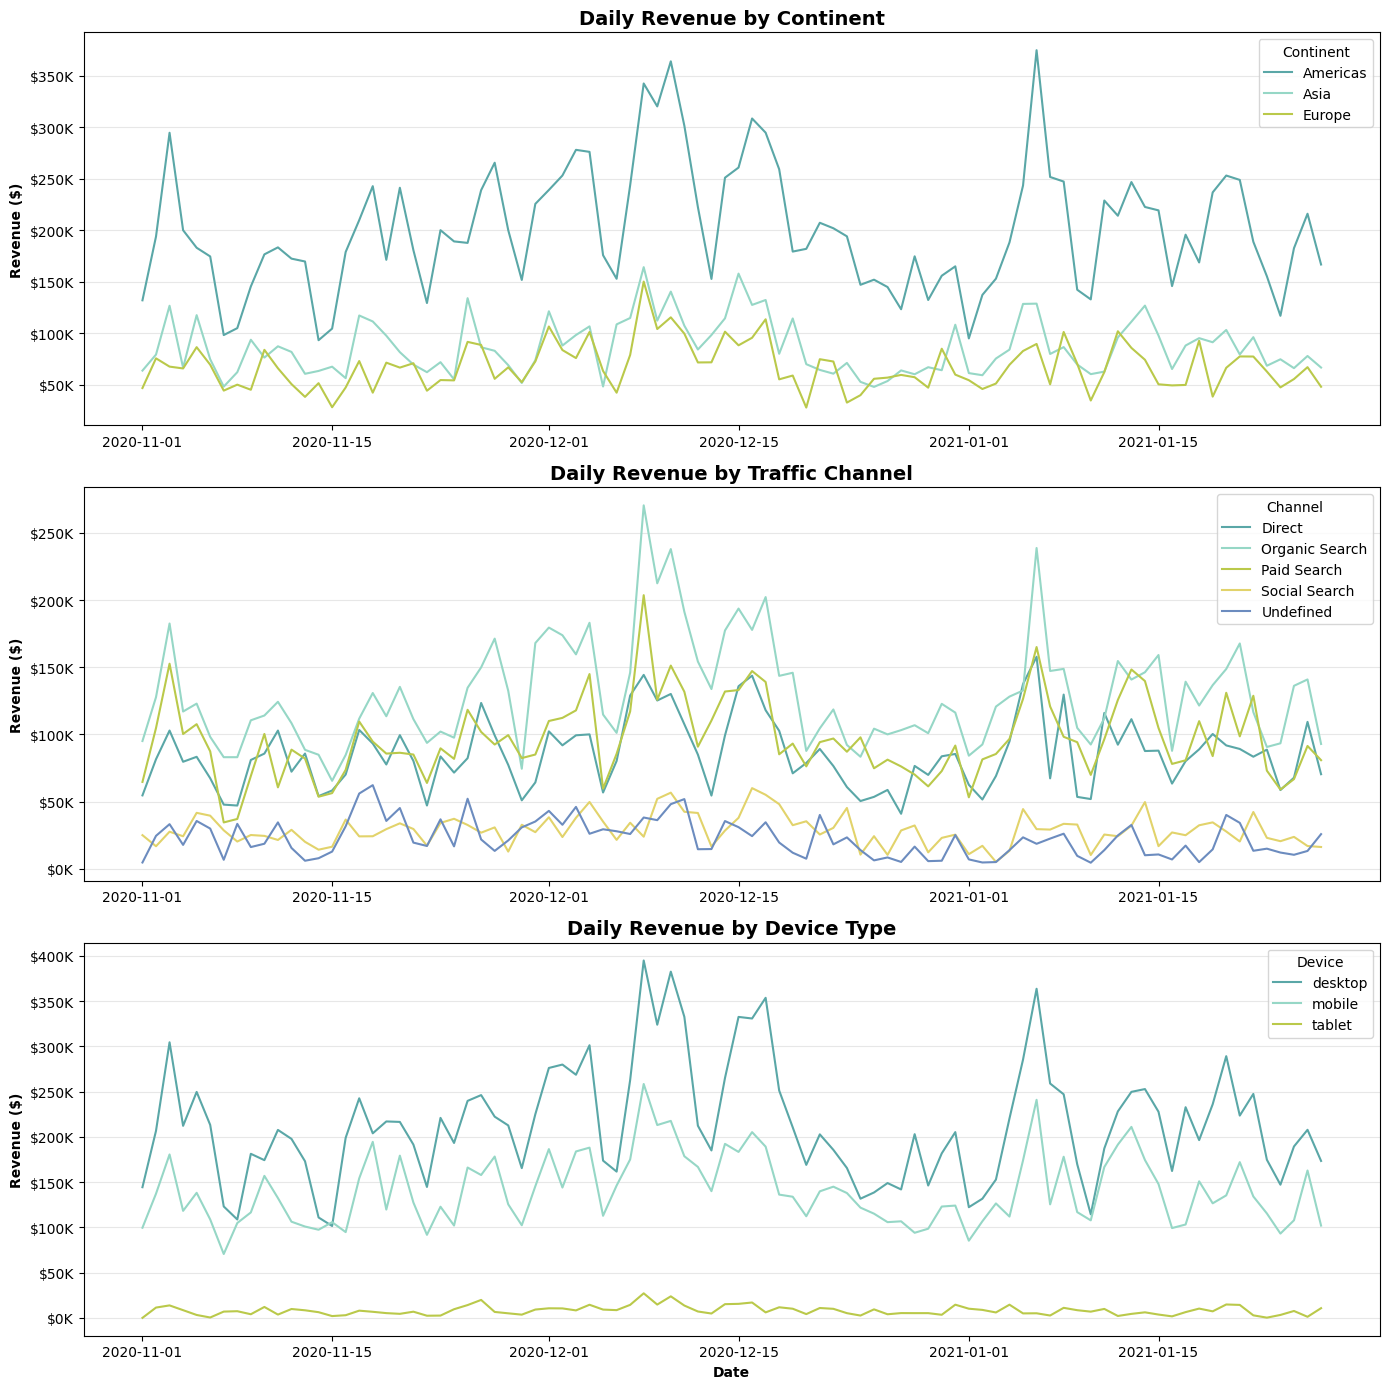

In [ ]:
# Visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Sales by Continent
for i, continent in enumerate(["Americas", "Asia", "Europe"]):
    df = continent_daily[continent_daily["continent"] == continent]
    axes[0].plot(df["date"], df["revenue"], color=colors[i],
                 linewidth=1.5, label=continent)

axes[0].set_title("Daily Revenue by Continent", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Revenue ($)", fontsize=10, fontweight="bold")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e3:.0f}K"))
axes[0].legend(title="Continent")
axes[0].grid(axis="y", alpha=0.3)

# Sales by Traffic Channel
for i, channel in enumerate(channel_daily["channel"].unique()):
    df = channel_daily[channel_daily["channel"] == channel]
    axes[1].plot(df["date"], df["revenue"], color=colors[i],
                 linewidth=1.5, label=channel)

axes[1].set_title("Daily Revenue by Traffic Channel", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Revenue ($)", fontsize=10, fontweight="bold")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e3:.0f}K"))
axes[1].legend(title="Channel")
axes[1].grid(axis="y", alpha=0.3)

# Sales by Device
for i, device in enumerate(device_daily["device"].unique()):
    df = device_daily[device_daily["device"] == device]
    axes[2].plot(df["date"], df["revenue"], color=colors[i],
                 linewidth=1.5, label=device)

axes[2].set_title("Daily Revenue by Device Type", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Date", fontsize=10, fontweight="bold")
axes[2].set_ylabel("Revenue ($)", fontsize=10, fontweight="bold")
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e3:.0f}K"))
axes[2].legend(title="Device")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Revenue Dynamics**

**By Continent**

Americas consistently dominates revenue throughout the entire period, running roughly 2-3x higher than Asia and 3-4x higher than Europe. All three continents show the same December peak pattern, suggesting the holiday season effect is global rather than region-specific.

**By Traffic Channel**

Organic Search and Direct traffic are the top two channels throughout the period, moving in tandem. Paid Search follows closely, while Social Search and Undefined remain consistently low. All channels peaked simultaneously around December 10-15, confirming this was a store-wide event rather than channel-specific.

**By Device Type**

Desktop dominates revenue at roughly 2x mobile throughout the period. Both desktop and mobile follow the same trend pattern, peaking in mid-December. Tablet revenue is negligible and flat across all dates.

**Key Takeaway**

All three breakdowns show the **same peak in mid-December** — this strongly suggests a store-wide promotional event (e.g. holiday sale) rather than organic growth in any specific segment.

## **7. Pivot Analysis**


### **Sessions by Traffic Channel and Device**

In [ ]:
# Sessions by Traffic Channel and Device
pivot1 = (data[data["traffic_channel"].notna() & data["device"].notna()]
          .groupby(["traffic_channel", "device"])["session_id"]
          .count()
          .unstack(fill_value=0))
pivot1 = pivot1.loc[pivot1.sum(axis=1).sort_values(ascending=False).index]

print("Sessions by Traffic Channel and Device:")
print(pivot1.to_string())

Sessions by Traffic Channel and Device:
device           desktop  mobile  tablet
traffic_channel                         
Organic Search     72622   49014    2789
Paid Search        55167   37034    2140
Direct             47825   31745    1812
Social Search      16288   10988     638
Undefined          12527    8486     470


- **Organic Search** generates the highest number of sessions across all devices (72,622 desktop / 49,014 mobile), followed by Paid Search and Direct.
- **Desktop** dominates in every channel, consistently representing ~59% of sessions.

The device split is remarkably uniform across all channels, suggesting that traffic source does not influence device preference.

### **Total Sales by Category and Country**


In [ ]:
# Total Sales by Category (top 10) and Country (top 5)
top5_countries = country_sales.head(5)["country"].tolist()
top10_categories = category_sales.head(10)["category"].tolist()

pivot2 = (orders[orders["country"].isin(top5_countries) &
                 orders["category"].isin(top10_categories)]
          .groupby(["category", "country"])["price"]
          .sum()
          .unstack(fill_value=0)
          .round(0))
pivot2 = pivot2.loc[pivot2.sum(axis=1).sort_values(ascending=False).index]

print("\nTotal Sales by Category and Country ($):")
print(pivot2.to_string())


Total Sales by Category and Country ($):
country                             Canada    France     India  United Kingdom  United States
category                                                                                     
Sofas & armchairs                 692428.0  187735.0  788430.0        234812.0      3707144.0
Chairs                            417741.0  134029.0  544309.0        188519.0      2619774.0
Beds                              354772.0  116414.0  358320.0        133816.0      2213058.0
Bookcases & shelving units        278982.0   73830.0  364507.0        113988.0      1567607.0
Cabinets & cupboards              181802.0   59102.0  191888.0         71684.0       994546.0
Outdoor furniture                 185323.0   40486.0  162289.0         57002.0       929245.0
Tables & desks                    132678.0   42299.0  186158.0         49374.0       777865.0
Chests of drawers & drawer units   71952.0   21544.0   73111.0         36784.0       382388.0
Bar furniture     

- **Sofas & armchairs** is the top category in every country, with the US leading at $3.7M. Chairs rank second universally.
- The category ranking is consistent across all 5 countries — no country shows a unique preference for any category.
- The US outperforms other countries by a large revenue in every category, with India and Canada as distant second and third markets.

### **Average Order Value by Continent and Device**


In [ ]:
# Avg Order Value by Continent and Device
pivot3 = (orders.groupby(["continent", "device"])["price"]
          .mean()
          .unstack(fill_value=0)
          .round(2))
pivot3 = pivot3.loc[pivot3.sum(axis=1).sort_values(ascending=False).index]

print("\nAvg Order Value by Continent and Device ($):")
print(pivot3.to_string())


Avg Order Value by Continent and Device ($):
device     desktop   mobile   tablet
continent                           
Asia        940.15   971.46  1110.69
Africa     1030.02   907.48   987.14
Europe      955.43   935.09   978.02
Americas    962.17   936.26   966.60
Oceania    1039.48   942.73   847.78
(not set)  1032.87  1117.70    70.00


- **Asia** shows the highest avg order value on tablet (\$1,110) and mobile (\$971), while **Oceania** leads on desktop (\$1,039).
- **Americas and Europe** show the most balanced average order values across devices (~\$935-966).
- **Africa** shows a notable gap between desktop (\$1,030) and mobile (\$907), suggesting mobile users in Africa may prefer lower-priced products.

### **Orders by Traffic Channel and Month**


In [ ]:
# Orders by Traffic Channel and Month
orders_with_month = orders.copy()
orders_with_month["month"] = orders_with_month["order_date"].dt.to_period("M").astype(str)

pivot4 = (orders_with_month.groupby(["traffic_channel", "month"])["session_id"]
          .count()
          .unstack(fill_value=0))
pivot4 = pivot4.loc[pivot4.sum(axis=1).sort_values(ascending=False).index]

print("\nOrders by Traffic Channel and Month:")
print(pivot4.to_string())


Orders by Traffic Channel and Month:
month            2020-11  2020-12  2021-01
traffic_channel                           
Organic Search      3577     4654     3690
Paid Search         2786     3488     2768
Direct              2459     2962     2379
Social Search        905     1066      745
Undefined            813      733      513


- All channels peaked in **December 2020**, consistent with holiday season trends.
- **Organic Search** is the leading channel every month, followed by Paid Search and Direct.
- **Undefined** traffic declined from 813 in November to 513 in January, suggesting improved UTM tracking over time.
- **Social Search** shows the steepest relative decline in January (-30%), indicating lower post-holiday engagement from social platforms.

## **8. Correlation Analysis**


### **Sessions vs Revenue**


Sessions vs Revenue
   Pearson r:   0.9313
   P-value:     0.000000
   Significant: Yes


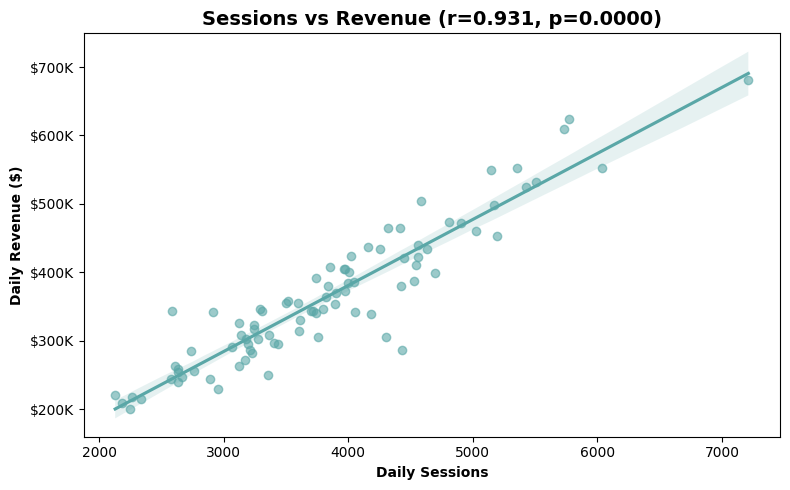

In [ ]:
# Sessions vs Revenue

daily_sessions = (data.groupby("order_date")["session_id"]
                  .count()
                  .reset_index())
daily_sessions.columns = ["date", "sessions"]
daily_corr = daily_sales.merge(daily_sessions, on="date")

corr1, pval1 = stats.pearsonr(daily_corr["sessions"], daily_corr["revenue"])
print("Sessions vs Revenue")
print(f"   Pearson r:   {corr1:.4f}")
print(f"   P-value:     {pval1:.6f}")
print(f"   Significant: {"Yes" if pval1 < 0.05 else "No"}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=daily_corr, x="sessions", y="revenue",
            color=colors[0], scatter_kws={"alpha": 0.6}, ax=ax)
ax.set_title(f"Sessions vs Revenue (r={corr1:.3f}, p={pval1:.4f})",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Daily Sessions", fontsize=10, fontweight="bold")
ax.set_ylabel("Daily Revenue ($)", fontsize=10, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"${x/1e3:.0f}K"))
plt.tight_layout()
plt.show()

There is a **very strong positive correlation between daily sessions
and daily revenue** (r=0.931).

This means that days with more traffic almost always generate more revenue. Revenue growth is primarily driven by traffic volume rather than changes in average order value.

### **Correlation Between Continents**


Correlation between continents:
   Americas vs Asia: r=0.6923, p=0.000000, significant=Yes
   Americas vs Europe: r=0.6695, p=0.000000, significant=Yes
   Asia vs Europe: r=0.6678, p=0.000000, significant=Yes


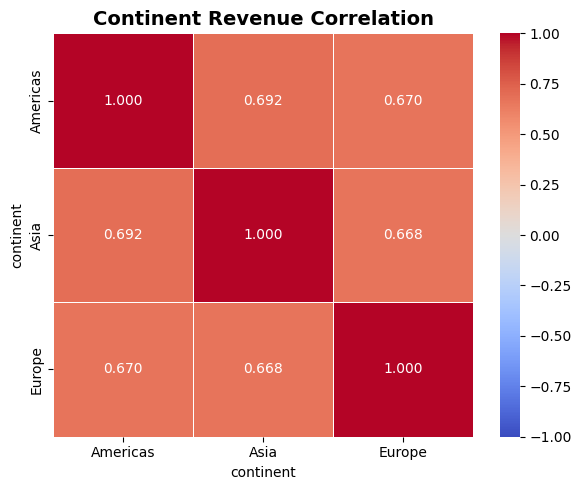

In [ ]:
# Correlation between continents
cont_pivot = (continent_daily.pivot(index="date", columns="continent", values="revenue")
              .fillna(0))

print("Correlation between continents:")
pairs = [("Americas", "Asia"), ("Americas", "Europe"), ("Asia", "Europe")]
for c1, c2 in pairs:
    r, p = stats.pearsonr(cont_pivot[c1], cont_pivot[c2])
    print(f"   {c1} vs {c2}: r={r:.4f}, p={p:.6f}, significant={"Yes" if p < 0.05 else "No"}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cont_pivot.corr(), annot=True, fmt=".3f", cmap="coolwarm",
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Continent Revenue Correlation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

All three continent pairs show **moderate positive correlations** (~0.67-0.69), all statistically significant.

Americas vs Asia shows the strongest relationship (r=0.692). This confirms the Time Series finding — all continents follow the same seasonal pattern, peaking in mid-December.

The moderate correlations suggest some degree of independent variation between regions.

### **Correlation Between Traffic Channels**


Correlation between traffic channels:
   Direct vs Organic Search: r=0.7599, p=0.000000, significant=Yes
   Direct vs Paid Search: r=0.7243, p=0.000000, significant=Yes
   Direct vs Social Search: r=0.4619, p=0.000006, significant=Yes
   Direct vs Undefined: r=0.4240, p=0.000038, significant=Yes
   Organic Search vs Paid Search: r=0.8082, p=0.000000, significant=Yes
   Organic Search vs Social Search: r=0.4344, p=0.000023, significant=Yes
   Organic Search vs Undefined: r=0.4354, p=0.000022, significant=Yes
   Paid Search vs Social Search: r=0.4523, p=0.000010, significant=Yes
   Paid Search vs Undefined: r=0.4300, p=0.000029, significant=Yes
   Social Search vs Undefined: r=0.3593, p=0.000585, significant=Yes


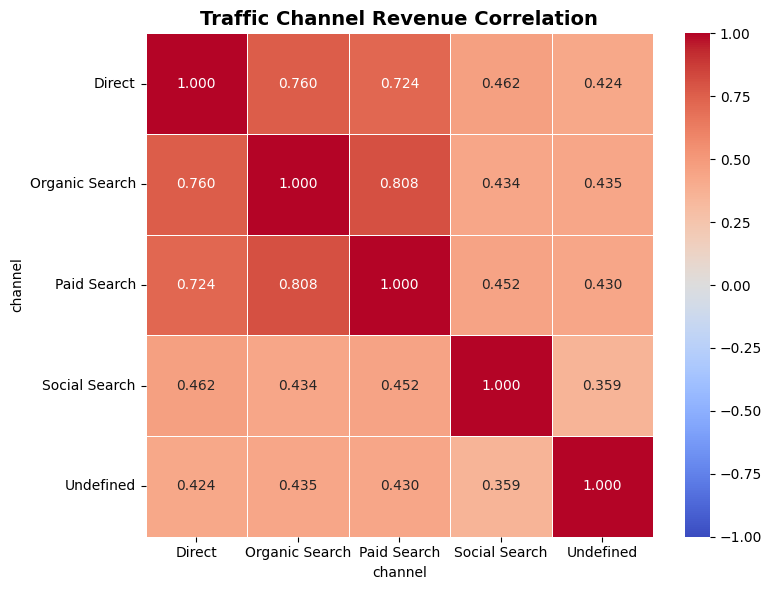

In [ ]:
# Correlation between traffic channels
ch_pivot = (channel_daily.pivot(index="date", columns="channel", values="revenue")
            .fillna(0))

print("Correlation between traffic channels:")
channels = ch_pivot.columns.tolist()
for i in range(len(channels)):
    for j in range(i + 1, len(channels)):
        r, p = stats.pearsonr(ch_pivot[channels[i]], ch_pivot[channels[j]])
        print(f"   {channels[i]} vs {channels[j]}: r={r:.4f}, p={p:.6f}, significant={"Yes" if p < 0.05 else "No"}")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ch_pivot.corr(), annot=True, fmt=".3f", cmap="coolwarm",
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Traffic Channel Revenue Correlation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

All channel pairs are **positively correlated** and statistically significant.

The strongest relationship is between **Organic Search** and **Paid Search** (r=0.808), suggesting these two channels move together — likely both responding to the same demand signals or promotional events.

**Social Search** and **Undefined** show weaker correlations with other channels (r~0.36-0.46), indicating more independent behavior.

### **Correlation Between Top 5 Categories**

Correlation between top 5 categories:
   Sofas & armchairs vs Chairs: r=0.5782, p=0.000000, significant=Yes
   Sofas & armchairs vs Beds: r=0.5354, p=0.000000, significant=Yes
   Sofas & armchairs vs Bookcases & shelving units: r=0.6662, p=0.000000, significant=Yes
   Sofas & armchairs vs Cabinets & cupboards: r=0.6576, p=0.000000, significant=Yes
   Chairs vs Beds: r=0.5545, p=0.000000, significant=Yes
   Chairs vs Bookcases & shelving units: r=0.6371, p=0.000000, significant=Yes
   Chairs vs Cabinets & cupboards: r=0.5729, p=0.000000, significant=Yes
   Beds vs Bookcases & shelving units: r=0.5929, p=0.000000, significant=Yes
   Beds vs Cabinets & cupboards: r=0.5146, p=0.000000, significant=Yes
   Bookcases & shelving units vs Cabinets & cupboards: r=0.5394, p=0.000000, significant=Yes


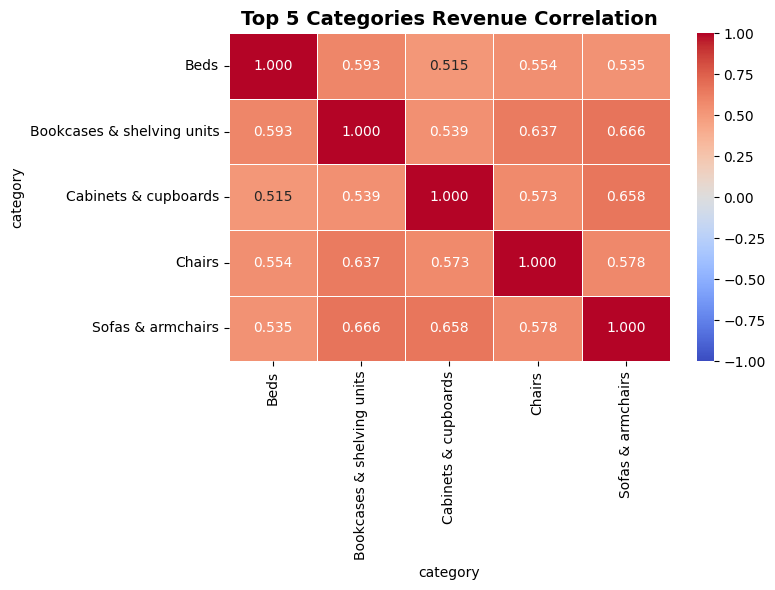

In [ ]:
# Correlation between top 5 categories
top5_cats = category_sales.head(5)["category"].tolist()
cat_pivot = (orders[orders["category"].isin(top5_cats)]
             .groupby(["order_date", "category"])["price"]
             .sum()
             .unstack(fill_value=0))

print("Correlation between top 5 categories:")
for i in range(len(top5_cats)):
    for j in range(i + 1, len(top5_cats)):
        r, p = stats.pearsonr(cat_pivot[top5_cats[i]], cat_pivot[top5_cats[j]])
        print(f"   {top5_cats[i]} vs {top5_cats[j]}: r={r:.4f}, p={p:.6f}, significant={"Yes" if p < 0.05 else "No"}")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cat_pivot.corr(), annot=True, fmt=".3f", cmap="coolwarm",
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Top 5 Categories Revenue Correlation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

All category pairs show **moderate positive correlations** (r=0.51-0.67),
all statistically significant.

The strongest pair is **Sofas & armchairs vs Bookcases & shelving units** (r=0.666), while the weakest is **Beds vs Cabinets & cupboards** (r=0.515). This suggests customers tend to browse and purchase across multiple furniture categories simultaneously — consistent with home furnishing behavior where people outfit entire rooms at once.

## **9. Statistical Tests**


### **Mann-Whitney U: Registered vs Guest Order Values**

**Hypothesis:** Do registered and guest users spend different amounts per order?

In [ ]:
# Mann-Whitney U: Registered vs Guest order values
registered_orders = orders[orders["account_id"].notna()]["price"]
guest_orders = orders[orders["account_id"].isna()]["price"]

print(f"Registered orders: {len(registered_orders):,}, mean=${registered_orders.mean():.2f}")
print(f"Guest orders:      {len(guest_orders):,}, mean=${guest_orders.mean():.2f}")

stat1, pval1 = stats.mannwhitneyu(registered_orders, guest_orders,
                                   alternative="two-sided")
print(f"\nMann-Whitney U: Registered vs Guest Order Values")
print(f"   Statistic: {stat1:.2f}")
print(f"   P-value:   {pval1:.6f}")
print(f"   Significant: {"Yes" if pval1 < 0.05 else "No"}")

Registered orders: 2,781, mean=$928.63
Guest orders:      30,757, mean=$955.53

Mann-Whitney U: Registered vs Guest Order Values
   Statistic: 41771375.00
   P-value:   0.041591
   Significant: Yes


The test confirms a statistically significant difference between registered and guest order values. However, the practical difference is small — guest users spend only **\$26.90 more** on average (\$955 vs $929).

This suggests that while the difference is statistically real, it is not
practically meaningful for business decisions. Registered users do not
necessarily spend more per order.

### **Kruskal-Wallis: Daily Sessions by Traffic Channel**

**Hypothesis:** Are there significant differences in daily session counts across traffic channels?

In [ ]:
# Kruskal-Wallis: Sessions by Traffic Channel
channel_groups = [
    data[data["traffic_channel"] == ch].groupby("order_date")["session_id"].count().values
    for ch in data["traffic_channel"].unique()
]

channel_names = data["traffic_channel"].unique().tolist()

for name, group in zip(channel_names, channel_groups):
    print(f"{name}: mean={group.mean():.1f}, median={np.median(group):.1f}")

stat2, pval2 = stats.kruskal(*channel_groups)
print(f"\nKruskal-Wallis: Daily Sessions by Traffic Channel")
print(f"   Statistic: {stat2:.4f}")
print(f"   P-value:   {pval2:.6f}")
print(f"   Significant: {"Yes" if pval2 < 0.05 else "No"}")

Paid Search: mean=1025.4, median=989.0
Organic Search: mean=1352.4, median=1329.0
Direct: mean=884.6, median=869.5
Undefined: mean=233.5, median=229.0
Social Search: mean=303.4, median=308.0

Kruskal-Wallis: Daily Sessions by Traffic Channel
   Statistic: 368.9806
   P-value:   0.000000
   Significant: Yes


There are highly significant differences in daily session counts across
traffic channels. Organic Search dominates with 1,352 sessions/day on
average — 32% more than Paid Search (1,025) and 53% more than Direct (885).

Social Search and Undefined contribute significantly fewer sessions,
suggesting limited investment or reach in these channels.

### **Chi-square: Organic Traffic Share — Europe vs Americas**

**Hypothesis:** Is the share of organic traffic different in Europe vs Americas?

In [ ]:
# Chi-square: Organic traffic share Europe vs Americas
europe_sessions = data[data["continent"] == "Europe"]
americas_sessions = data[data["continent"] == "Americas"]

europe_organic = (europe_sessions["traffic_channel"] == "Organic Search").sum()
europe_other = (europe_sessions["traffic_channel"] != "Organic Search").sum()

americas_organic = (americas_sessions["traffic_channel"] == "Organic Search").sum()
americas_other = (americas_sessions["traffic_channel"] != "Organic Search").sum()

contingency = [[europe_organic, europe_other],
               [americas_organic, americas_other]]

stat3, pval3, dof, expected = stats.chi2_contingency(contingency)

europe_pct = europe_organic / len(europe_sessions) * 100
americas_pct = americas_organic / len(americas_sessions) * 100

print("Chi-square: Organic Traffic Share — Europe vs Americas")
print(f"   Europe:   organic={europe_organic:,} ({europe_pct:.1f}%)")
print(f"   Americas: organic={americas_organic:,} ({americas_pct:.1f}%)")
print(f"   Chi2:      {stat3:.4f}")
print(f"   P-value:   {pval3:.6f}")
print(f"   DoF:       {dof}")
print(f"   Significant: {"Yes" if pval3 < 0.05 else "No"}")

Chi-square: Organic Traffic Share — Europe vs Americas
   Europe:   organic=23,195 (35.6%)
   Americas: organic=68,671 (35.5%)
   Chi2:      0.0811
   P-value:   0.775811
   DoF:       1
   Significant: No


The share of organic traffic is virtually identical in Europe (35.6%)
and Americas (35.5%) — a difference of only 0.1 percentage points.

The test confirms this difference is **not statistically significant** (p=0.776), meaning organic search behavior is consistent across both continents.

### **Mann-Whitney U: Subscribed vs Unsubscribed Order Values**

**Hypothesis:** Do subscribed and unsubscribed users spend different
amounts per order?

In [ ]:
# Mann-Whitney U: Subscribed vs Unsubscribed order values
stat4, pval4 = stats.mannwhitneyu(subscribed_orders["price"],
                                   unsubscribed_orders["price"],
                                   alternative="two-sided")
print("Mann-Whitney U: Subscribed vs Unsubscribed Order Values")
print(f"   Subscribed mean:   ${subscribed_orders['price'].mean():.2f}")
print(f"   Unsubscribed mean: ${unsubscribed_orders['price'].mean():.2f}")
print(f"   Statistic: {stat4:.2f}")
print(f"   P-value:   {pval4:.6f}")
print(f"   Significant: {"Yes" if pval4 < 0.05 else "No"}")

Mann-Whitney U: Subscribed vs Unsubscribed Order Values
   Subscribed mean:   $921.51
   Unsubscribed mean: $965.82
   Statistic: 500198.00
   P-value:   0.167802
   Significant: No


Despite unsubscribed users spending slightly more on average (\$965 vs \$922), the difference is **not statistically significant** (p=0.168) — it could be due to chance.

Email subscription status does not influence how much users spend per order. Unsubscribing from the mailing list does not change purchasing behavior in terms of order value.

### **Kruskal-Wallis: Order Values by Device Type**

**Hypothesis:** Are there significant differences in order values
across device types?

In [ ]:
# Kruskal-Wallis: Order values by device
device_groups = [
    orders[orders["device"] == d]["price"].values
    for d in orders["device"].unique()
]

device_names = orders["device"].unique().tolist()

for name, group in zip(device_names, device_groups):
    print(f"{name}: mean=${group.mean():.2f}, median=${np.median(group):.2f}")

stat5, pval5 = stats.kruskal(*device_groups)
print(f"\nKruskal-Wallis: Order Values by Device Type")
print(f"   Statistic: {stat5:.4f}")
print(f"   P-value:   {pval5:.6f}")
print(f"   Significant: {"Yes" if pval5 < 0.05 else "No"}")

desktop: mean=$957.47, median=$445.00
mobile: mean=$944.42, median=$435.00
tablet: mean=$1000.64, median=$495.00

Kruskal-Wallis: Order Values by Device Type
   Statistic: 4.1936
   P-value:   0.122849
   Significant: No


**No statistically significant differences** in order values across device types (p=0.123).

Interestingly, tablet users show the highest mean (\$1,000) and median
(\$495) order values, but this difference could be due to chance given the small tablet sample size (only 2.26% of all orders).

The large gap between mean and median for all devices confirms the right-skewed price distribution observed earlier — a small number of high-value orders pulls the mean up significantly.

## **10. Key Insights**

**Revenue & Growth**
- The store generated **\$31.97M** in revenue from **33,538 orders**   across **108 countries** in just 91 days
- December 2020 was the strongest month (\$12.4M), driven by holiday shopping — 28% higher than November and January
- Revenue is strongly driven by traffic volume (r=0.931) rather than changes in average order value

**Geography**
- **Americas generate 55.25%** of total revenue, with the US alone accounting for 43.61% — a more extreme concentration than the classic 80/20 Pareto rule (13.9% of countries = 80% of revenue)
- India and Canada are strong secondary markets with significant growth potential

**Products**
- Top 3 categories (Sofas & armchairs, Chairs, Beds) account for **60.86%** of all revenue
- Category preferences are identical across all countries and devices — no regional or device-specific product trends were found

**Users & Conversion**
- Only **9.59%** of sessions result in a purchase
- Registered users convert at nearly the same rate as guests (9.95% vs 9.56%) — registration provides no measurable lift
- **83%** of registered users remain subscribed to the mailing list, but email subscription status does not significantly affect order value

**Traffic & Devices**
- **Organic Search** is the top channel (35.76% of revenue, 1,352 sessions/day) — the store has strong SEO visibility
- **Desktop dominates** with 59% of sales despite mobile representing 38.73% — consistent with high-consideration furniture purchases
- All traffic channels and devices peaked simultaneously in mid-December, confirming a store-wide seasonal event

**Statistical Findings**
- Guest users spend slightly more per order (\$955 vs \$929), confirmed statistically significant but not practically meaningful
- No significant differences in order values across devices or subscription status

## **11. Business Recommendations**

**1. Reduce Geographic Concentration Risk**

The US market generates 43.61% of revenue — over-reliance on a single
market is a business risk. Invest in localized marketing campaigns for
India and Canada, which already show strong organic demand.

**2. Improve Conversion Rate**

At 9.59%, there is significant room to improve. Consider A/B testing
checkout flow simplification, exit-intent popups, and abandoned cart
recovery emails.

**3. Add Registration Incentives**

Registered users convert at only 0.39% more than guests. Introduce
loyalty points, exclusive discounts, or wishlists to make registration
more valuable and increase repeat purchase rates.

**4. Capitalize on December Peak**

The mid-December spike suggests a successful holiday campaign. Plan
earlier (late November) and extend promotions into January to reduce
the post-holiday revenue drop.

**5. Invest in Organic Search**

Organic Search is the #1 revenue channel at 35.76%. Continue SEO
investment and consider expanding content marketing to maintain and
grow this cost-effective channel.

**6. Fix UTM Tracking**

6.26% of revenue comes from Undefined traffic — likely sessions with
missing UTM parameters. Fixing tracking will improve attribution
accuracy and marketing ROI measurement.

**7. Mobile Experience**

Mobile accounts for 38.73% of sales. While desktop still dominates,
mobile is significant. Invest in mobile UX optimization, particularly
for product browsing and checkout, to capture more mobile conversions.